# Laboratorium 5:  Aproksymacja
Jakub Fabia

## Importowanie bibliotek

Importuję niezbędne biblioteki. Biblioteki te obejmują:
- `CSV` do pracy z plikami CSV,
- `DataFrames` do manipulacji danymi w formie tabelarycznej,
- `Plots` do tworzenia wykresów,
- `Statistics` do obliczeń statystycznych,
- `TaylorSeries` do przybliżania funkcji szeregiem Taylora,
- `Polynomials` do pracy z wielomianami i ich dopasowywania.

In [3]:
using DataFrames
using Plots
using Statistics
using CSV
using Polynomials
using TaylorSeries

## Zadanie 1/2

In [2]:
function naive_multiplication(A,B)
    C = zeros(Float64, size(A,1), size(B,2))
    for i=1:size(A,1)
        for j=1:size(B,2)
            for k=1:size(A,2)
                C[i,j] = C[i,j] + A[i,k]*B[k,j]
            end
        end
    end
    C
end

naive_multiplication (generic function with 1 method)

In [3]:
function better_multiplication(A, B)
    C = zeros(Float64, size(A,1), size(B,2))
    for j=1:size(B,2)
        for k=1:size(A,2)
            for i=1:size(A,1)
                C[i,j] = C[i,j] + A[i,k]*B[k,j]
            end
        end
    end
    C
end

better_multiplication (generic function with 1 method)

In [4]:
function benchmark_functions(sizes, num_trials)
    open("app/Lab5/Assignment/resultsJulia.csv", "w") do file
        CSV.write(file, [], writeheader=true, header=["size", "sample", "time_naive", "time_better", "time_blas"])
        for n in sizes
            for i in -1:num_trials-1
                
                A = rand(n, n)
                B = rand(n, n)
                
                time_naive = @elapsed naive_multiplication(A,B);
                time_better = @elapsed better_multiplication(A, B);
                time_blas = @elapsed A*B;

                # Skip the first sample, as it measures the compilation time
                if i != -1
                    CSV.write(file, [(n, i, time_naive, time_better, time_blas)], append=true)
                end
            end
        end
    end
end

benchmark_functions (generic function with 1 method)

In [5]:
sizes = 10:50:1010
benchmark_functions(sizes, 10)

Kodu w C nie będę tutaj wstawiał, wyniki jego działania zapisuje do pliku CSV w takim samym formacie jak ten wygenerowany przez komórkę powyżej.

In [54]:
for (path, res_df) in [("resultsJulia.csv", dfJulia), ("resultsO0.csv", dfO0), ("resultsO1.csv", dfO1), ("resultsO2.csv", dfO2), ("resultsO3.csv", dfO3), ("resultsO4.csv", dfO4)]
    input = "app/Lab5/Assignment/" * path
    res_df = CSV.read(input, delim=",", DataFrame)
end

In [55]:
for (res, input) in [(plot_dfJulia, dfJulia), (plot_dfO0, dfO0), (plot_dfO1, dfO1), (plot_dfO2, dfO2), (plot_dfO3, dfO3), (plot_dfO4, dfO4)]
    res = combine(
        groupby(input, :"size"), 
        "time_naive" => mean, 
        "time_naive" => std, 
        "time_better" => mean, 
        "time_better" => std,
        "time_blas" => mean, 
        "time_blas" => std
    )
end

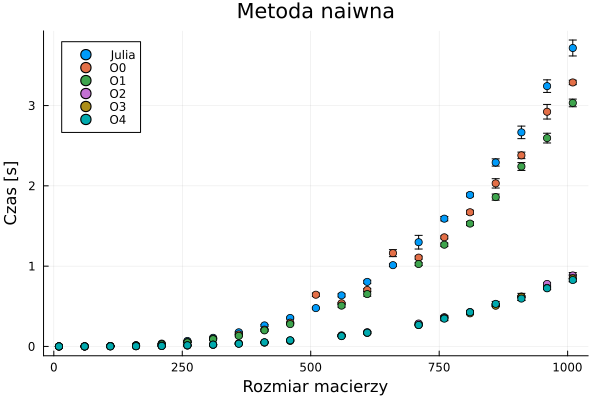

In [56]:
p1 = scatter(
    plot_dfJulia.size, 
    plot_dfJulia.time_naive_mean, 
    yerr = plot_dfJulia.time_naive_std,
    xlabel = "Rozmiar macierzy", 
    ylabel = "Czas [s]", 
    title = "Metoda naiwna", 
    label="Julia"
)
for (loop_df, plotlabel) in [(plot_dfO0, "O0"), (plot_dfO1, "O1"), (plot_dfO2, "O2"), (plot_dfO3, "O3"), (plot_dfO4, "O4")]
    scatter!(
        loop_df.size, 
        loop_df.time_naive_mean, 
        yerr = loop_df.time_naive_std,
        label=plotlabel
    )
end
p1

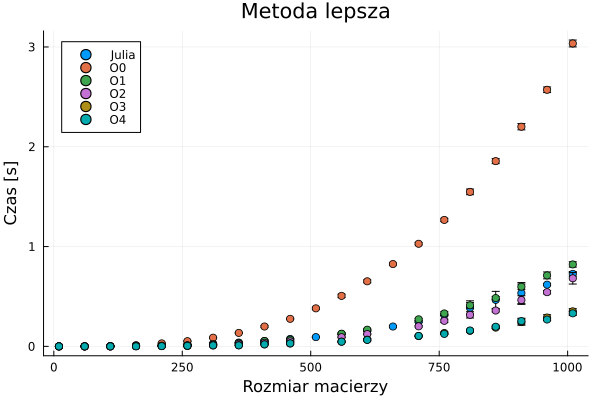

In [57]:
p1 = scatter(
    plot_dfJulia.size, 
    plot_dfJulia.time_better_mean, 
    yerr = plot_dfJulia.time_better_std,
    xlabel = "Rozmiar macierzy", 
    ylabel = "Czas [s]", 
    title = "Metoda lepsza", 
    label="Julia"
)
for (loop_df, plotlabel) in [(plot_dfO0, "O0"), (plot_dfO1, "O1"), (plot_dfO2, "O2"), (plot_dfO3, "O3"), (plot_dfO4, "O4")]
    scatter!(
        loop_df.size, 
        loop_df.time_better_mean, 
        yerr = loop_df.time_better_std,
        label=plotlabel
    )
end
p1

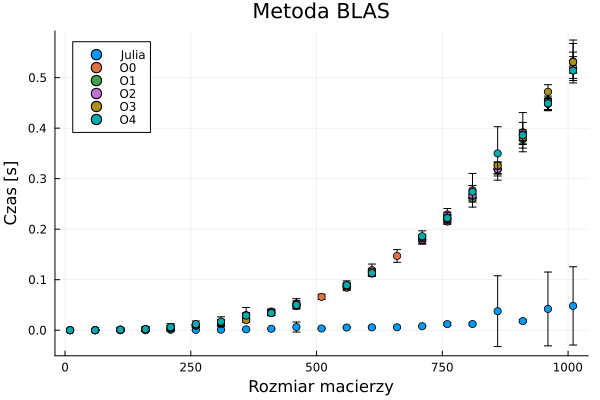

In [58]:
p1 = scatter(
    plot_dfJulia.size, 
    plot_dfJulia.time_blas_mean, 
    yerr = plot_dfJulia.time_blas_std,
    xlabel = "Rozmiar macierzy", 
    ylabel = "Czas [s]", 
    title = "Metoda BLAS", 
    label="Julia"
)
for (loop_df, plotlabel) in [(plot_dfO0, "O0"), (plot_dfO1, "O1"), (plot_dfO2, "O2"), (plot_dfO3, "O3"), (plot_dfO4, "O4")]
    scatter!(
        loop_df.size, 
        loop_df.time_blas_mean, 
        yerr = loop_df.time_blas_std,
        label=plotlabel
    )
end
p1

## Zadnie 3

Do metody naiwnej i lepszej dpoasowuje wielomiany 3 stopnia (zgodnie z ilością forów).
W źródłach znalazłem, że algorytm blas ma złożoność powyżej n^2.7 jednak BLAS wykorzystuje wielowątkowość, więc zakładam, że jego złożoność jest bliżej n^2.

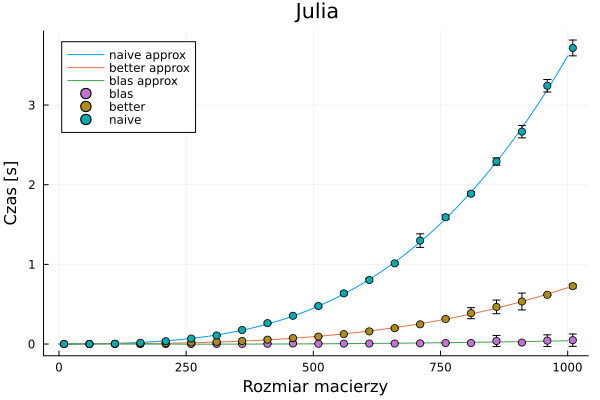

In [59]:
fit1 = fit(plot_dfJulia.size, plot_dfJulia.time_naive_mean, 3)
fit2 = fit(plot_dfJulia.size, plot_dfJulia.time_better_mean, 3)
fit3 = fit(plot_dfJulia.size, plot_dfJulia.time_blas_mean, 2)
xs = 0:1:1000
plot(fit1,extrema(xs)...,label="naive approx", xlabel = "Rozmiar macierzy", ylabel = "Czas [s]", title = "Julia")
plot!(fit2,extrema(xs)...,label="better approx")
plot!(fit3,extrema(xs)...,label="blas approx")
scatter!(
    plot_dfJulia.size, 
    plot_dfJulia.time_blas_mean, 
    yerr = plot_dfJulia.time_blas_std,
    label = "blas")
scatter!(
    plot_dfJulia.size, 
    plot_dfJulia.time_better_mean, 
    yerr = plot_dfJulia.time_better_std,
    label = "better")
scatter!(
    plot_dfJulia.size, 
    plot_dfJulia.time_naive_mean, 
    yerr = plot_dfJulia.time_naive_std,
    label = "naive")

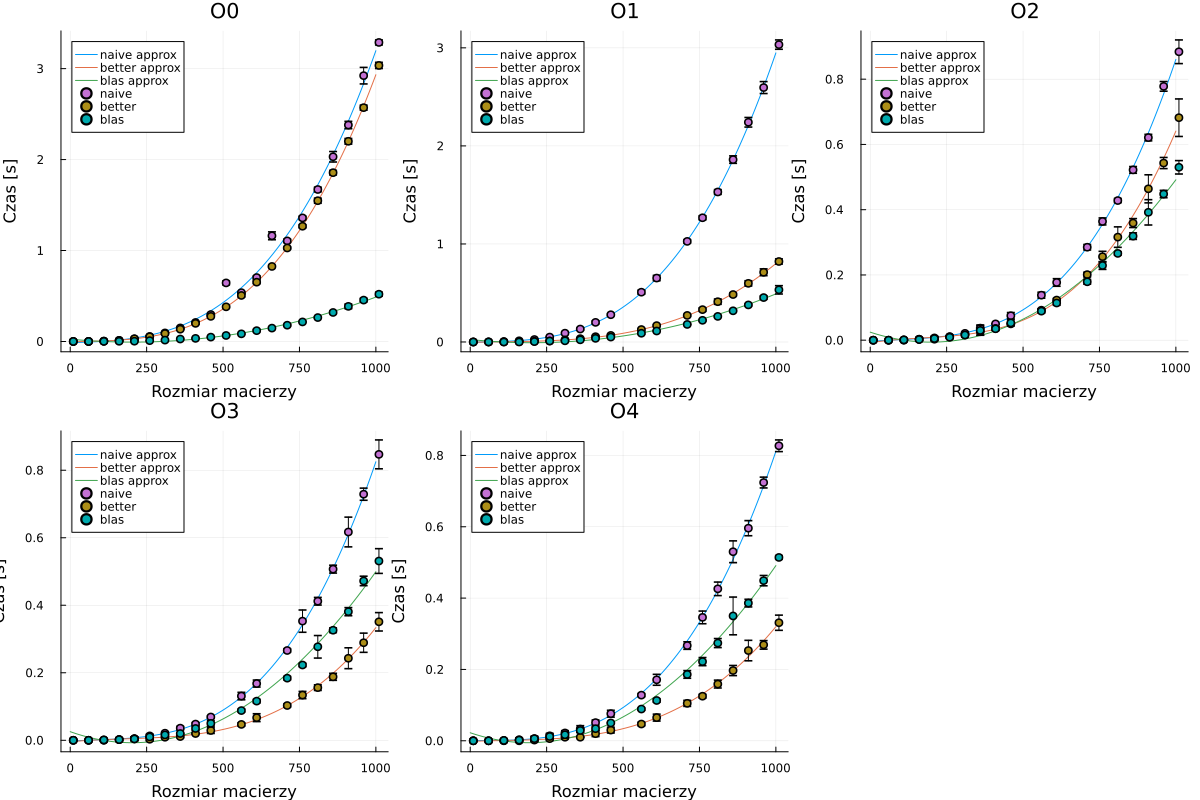

In [60]:
function plot_and_fit(data, title)
    fit_naive = fit(data.size, data.time_naive_mean, 3)
    fit_better = fit(data.size, data.time_better_mean, 3)
    fit_blas = fit(data.size, data.time_blas_mean, 2)
    
    xs = 0:1:1000
    p = plot(fit_naive, extrema(xs)..., label="naive approx", xlabel="Rozmiar macierzy", ylabel="Czas [s]", legend=:topleft, title=title)
    plot!(fit_better, extrema(xs)..., label="better approx")
    plot!(fit_blas, extrema(xs)..., label="blas approx")
    scatter!(data.size, data.time_naive_mean, yerr=data.time_naive_std, label="naive")
    scatter!(data.size, data.time_better_mean, yerr=data.time_better_std, label="better")
    scatter!(data.size, data.time_blas_mean, yerr=data.time_blas_std, label="blas")
    return p
end

datasets = [
    (plot_dfO0, "O0"),
    (plot_dfO1, "O1"),
    (plot_dfO2, "O2"),
    (plot_dfO3, "O3"),
    (plot_dfO4, "O4")
]

plots = [plot_and_fit(data, title) for (data, title) in datasets]
plot(plots..., layout=(2, 3), size=(1200, 800))

W powyższej analizie zauważyłem ciekawą anomalię, wszystkie optymalizacje (za wyjątkiem O0) dla macierzy o rozmiarze 510 oraz 660 wykazywały znacznie wyższy od oczekiwanego czas wykonania.

In [61]:
filter!(row -> row.size != 510 && row.size != 660, plot_dfO1)
filter!(row -> row.size != 510 && row.size != 660, plot_dfO2)
filter!(row -> row.size != 510 && row.size != 660, plot_dfO3)
filter!(row -> row.size != 510 && row.size != 660, plot_dfO4)

Row,size,time_naive_mean,time_naive_std,time_better_mean,time_better_std,time_blas_mean,time_blas_std
,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,10,0.0,0.0,0.0,0.0,0.0,0.0
2,60,0.0,0.0,0.0,0.0,0.0,0.0
3,110,0.001,0.00316228,0.0,0.0,0.001,0.00316228
4,160,0.003,0.00483046,0.0,0.0,0.002,0.00421637
5,210,0.006,0.00516398,0.002,0.00421637,0.006,0.00699206
6,260,0.014,0.00699206,0.006,0.00516398,0.012,0.00632456
7,310,0.022,0.00632456,0.01,0.00471405,0.017,0.00948683
8,360,0.033,0.00948683,0.01,1.82856e-18,0.029,0.00567646
9,410,0.051,0.00737865,0.02,0.00816497,0.034,0.00516398


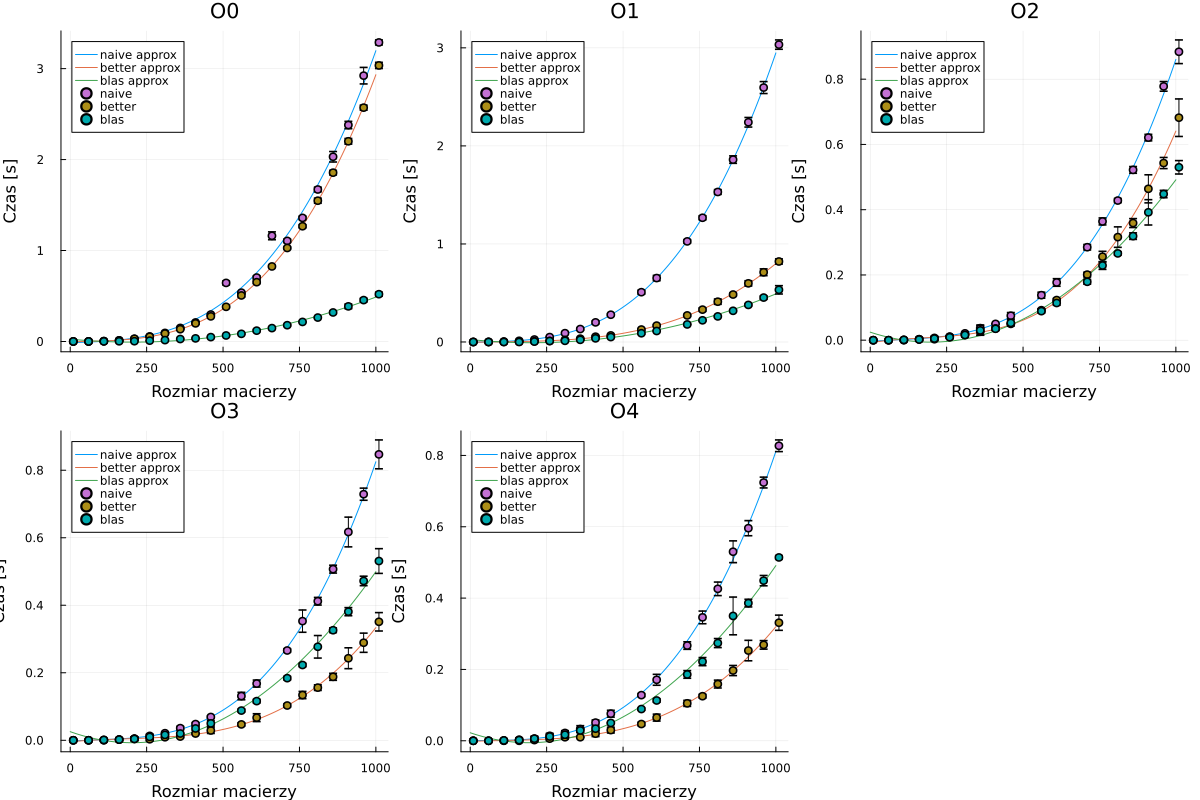

In [62]:
function plot_and_fit(data, title)
    fit_naive = fit(data.size, data.time_naive_mean, 3)
    fit_better = fit(data.size, data.time_better_mean, 3)
    fit_blas = fit(data.size, data.time_blas_mean, 2)
    
    xs = 0:1:1000
    p = plot(fit_naive, extrema(xs)..., label="naive approx", xlabel="Rozmiar macierzy", ylabel="Czas [s]", legend=:topleft, title=title)
    plot!(fit_better, extrema(xs)..., label="better approx")
    plot!(fit_blas, extrema(xs)..., label="blas approx")
    scatter!(data.size, data.time_naive_mean, yerr=data.time_naive_std, label="naive")
    scatter!(data.size, data.time_better_mean, yerr=data.time_better_std, label="better")
    scatter!(data.size, data.time_blas_mean, yerr=data.time_blas_std, label="blas")
    return p
end

datasets = [
    (plot_dfO0, "O0"),
    (plot_dfO1, "O1"),
    (plot_dfO2, "O2"),
    (plot_dfO3, "O3"),
    (plot_dfO4, "O4")
]

plots = [plot_and_fit(data, title) for (data, title) in datasets]
plot(plots..., layout=(2, 3), size=(1200, 800))

## Zadanie 4

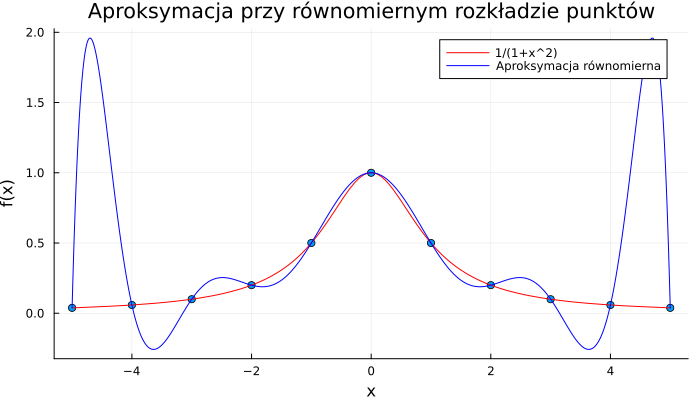

In [63]:
function target_function(x)
    1/(1 + x^2)
end

x_values = -5:1:5
y_values = [target_function(x) for x in x_values]
poly_approximation = fit(x_values, y_values, 10)

x_fine = -5:0.01:5
y_fine = [poly_approximation(x) for x in x_fine]

scatter(
    x_values,
    y_values,
    label=:none,
    size=(700,400),
    title="Aproksymacja przy równomiernym rozkładzie punktów",
    xlabel="x",
    ylabel="f(x)"
)

plot!(
    target_function,
    extrema(x_values)...,
    label="1/(1+x^2)",
    color=:red
)

plot!(
    x_fine,
    y_fine,
    label="Aproksymacja równomierna",
    color=:blue
)

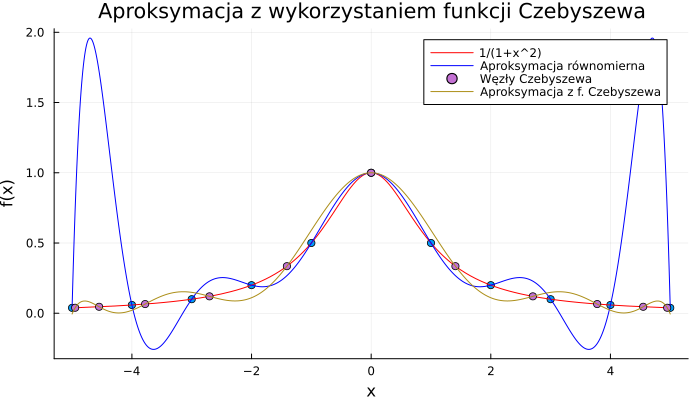

In [64]:
basis = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
chebyshev_poly = ChebyshevT(basis)
chebyshev_nodes = Polynomials.roots(chebyshev_poly)
chebyshev_nodes = 5 * chebyshev_nodes
y_chebyshev = [target_function(x) for x in chebyshev_nodes]

poly_approx_chebyshev = fit(chebyshev_nodes, y_chebyshev, 10)

scatter!(
    chebyshev_nodes,
    y_chebyshev,
    label="Węzły Czebyszewa",
    title="Aproksymacja z wykorzystaniem funkcji Czebyszewa"
)

y_fine_chebyshev = [poly_approx_chebyshev(x) for x in x_fine]
plot!(
    x_fine,
    y_fine_chebyshev,
    label="Aproksymacja z f. Czebyszewa",
)

## Zadanie 5

In [65]:
function_test(x) = log(1+x)/x

function_test (generic function with 1 method)

In [66]:
t = Taylor1(Float64, 5)
taylor_poly_base = function_test(t)

 1.0 - 0.5 t + 0.3333333333333333 t² - 0.25 t³ + 0.2 t⁴ + 𝒪(t⁵)

In [67]:
taylor_poly = Polynomial(taylor_poly_base.coeffs)

Polynomial(1.0 - 0.5*x + 0.3333333333333333*x^2 - 0.25*x^3 + 0.2*x^4)

In [68]:
pade_obj = Polynomials.PolyCompat.PadeApproximation.Pade(taylor_poly, 2, 2)

Polynomials.PolyCompat.PadeApproximation.Pade{Float64, Float64}(Polynomial(1.0 + 0.6999999999999987*x + 0.03333333333333298*x^2), Polynomial(1.0 + 1.1999999999999986*x + 0.29999999999999905*x^2), :x)

In [69]:
pade_val(x) = pade_obj.p(x) / pade_obj.q(x)
taylor_val(x) = taylor_poly(x)

taylor_val (generic function with 1 method)

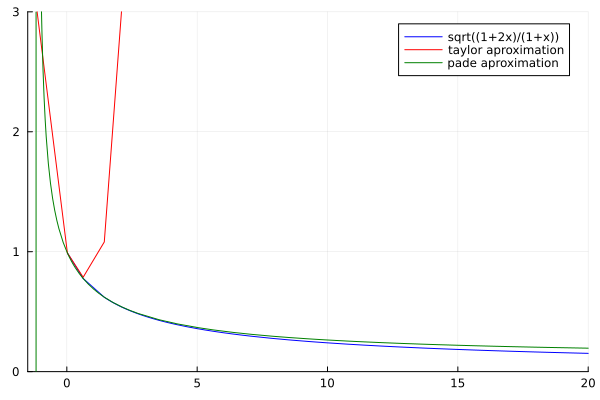

In [70]:
plot(function_test,
    xlims = (-1.5, 20),
    ylims = (0,3),
    label="sqrt((1+2x)/(1+x))",
    color = "blue"
)
plot!(taylor_val,
    label="taylor aproximation",
    color = "red"
)
plot!(pade_val,
    label="pade aproximation",
    color = "green"
)